# Nama  : Kevin Rafael Owen
# NIM   : 4222301038
# Kelas : RE B PAGI

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


## Exploratory Data Analysis

In [3]:
df.info

<bound method DataFrame.info of       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-seto

In [4]:
df.describe

<bound method NDFrame.describe of       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-se

In [5]:
print(list(df.columns))

['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


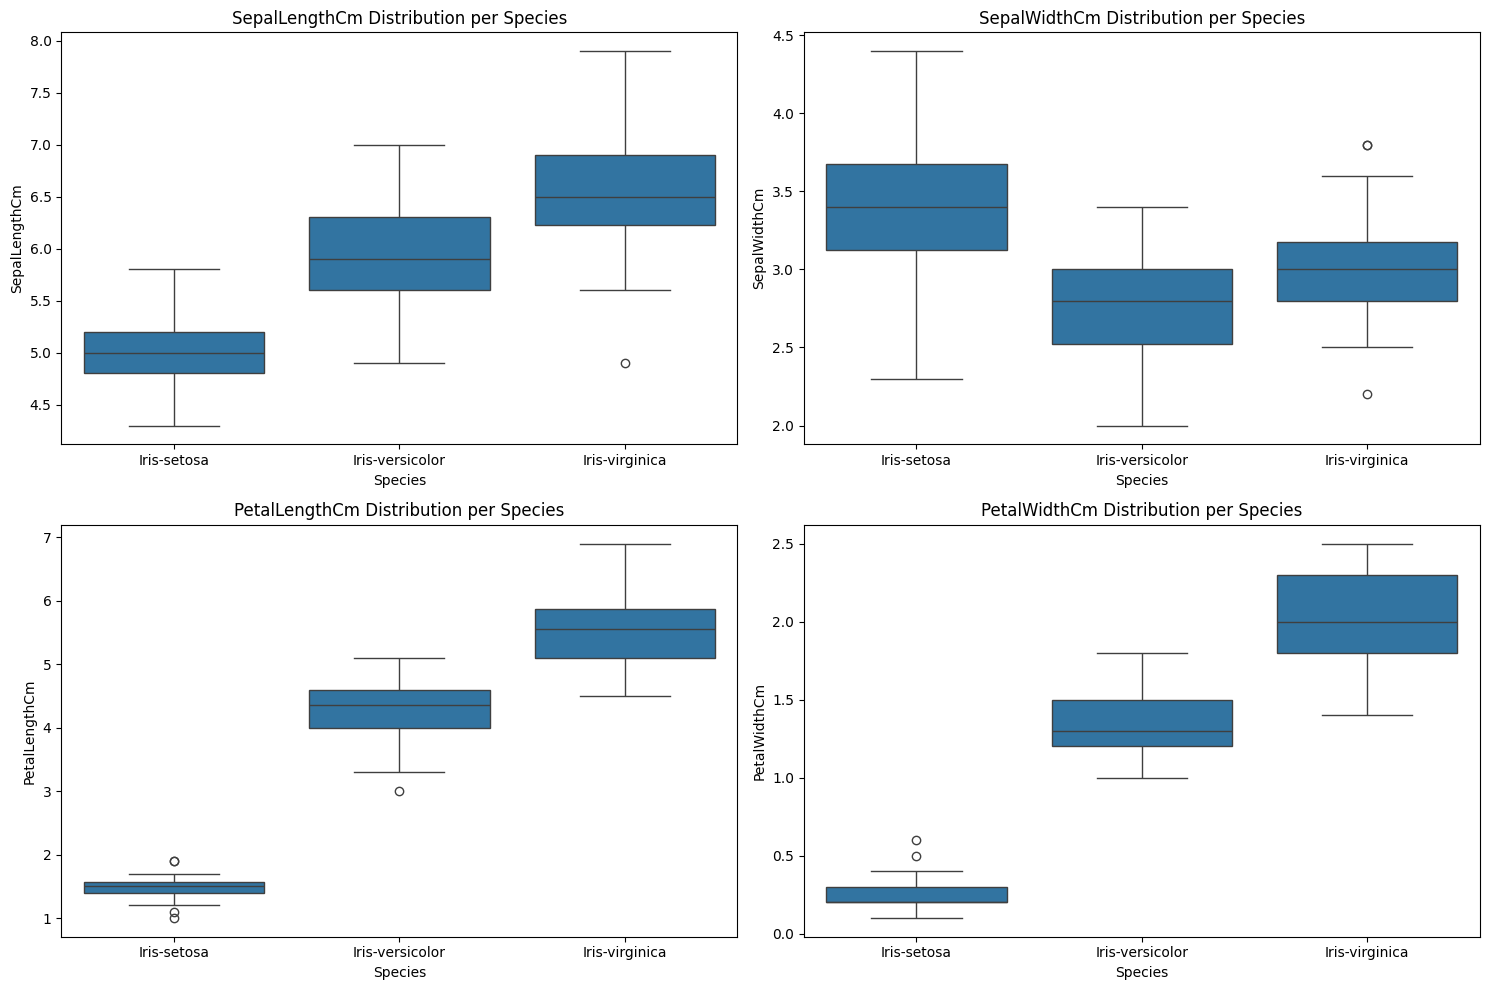

In [6]:
# Visualisasi Feature Distribution

plt.figure(figsize=(15, 10))
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='Species', y=feature, data=df)
    plt.title(f"{feature} Distribution per Species")
plt.tight_layout()
plt.show()

## Preprocessing

In [7]:
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['Species'])

In [8]:
# Feature yang akan dipakai
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# Feature dan Target
X = df[features].values
y = df['species_encoded'].values

In [9]:
# Bagi data (training/testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
# StandardScaler

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# Optimalisasi Evaluasi pada MLP

from sklearn.neural_network import MLPClassifier
def eval_mlp_optimasasi(name, activation, ax=None):
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation=activation,
        solver='adam',
        alpha=1e-4,
        batch_size=16,
        learning_rate='adaptive',
        learning_rate_init=0.005,
        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    )
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=le.classes_)

    # Plot loss
    if ax is not None:
        ax.plot(mlp.loss_curve_, label=f'{name} ({mlp.loss_curve_[-1]:.4f})')
        ax.set_title('Training Loss Curve')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True)

    return {
        'name': name,
        'accuracy': accuracy,
        'report': report,
        'loss_curve': mlp.loss_curve_,
        'n_iter': mlp.n_iter_,
        'final_loss': mlp.loss_curve_[-1],
        'model': mlp
    }

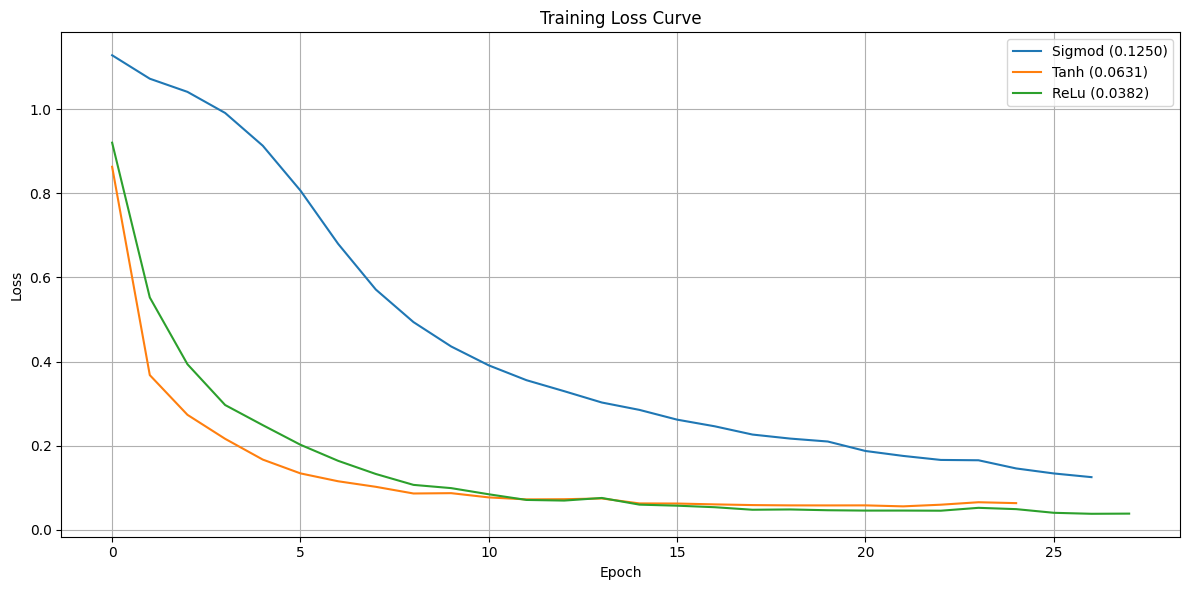

In [12]:
# Evaluasi pada semua Aktivisasi

activizations = [('Sigmod', 'logistic'), ('Tanh', 'tanh'), ('ReLu', 'relu')]
results = {}

plt.figure(figsize=(12, 6))
ax = plt.gca()

for name, act in activizations:
    results[name] = eval_mlp_optimasasi(name, act, ax=ax)

plt.tight_layout()
plt.show()


In [13]:
# Ringkasan Hasil

results_df = pd.DataFrame({
    'Fungsi Aktivasi': [res['name'] for res in results.values()],
    'Akurasi': [res['accuracy'] for res in results.values()],
    'Iterasi': [res['n_iter'] for res in results.values()],
    'Loss Akhir': [res['final_loss'] for res in results.values()]
})
results_df

,Fungsi Aktivasi,Akurasi,Iterasi,Loss Akhir
0,Sigmod,0.833333,27,0.124954
1,Tanh,0.900000,25,0.063121
2,ReLu,0.933333,28,0.038180


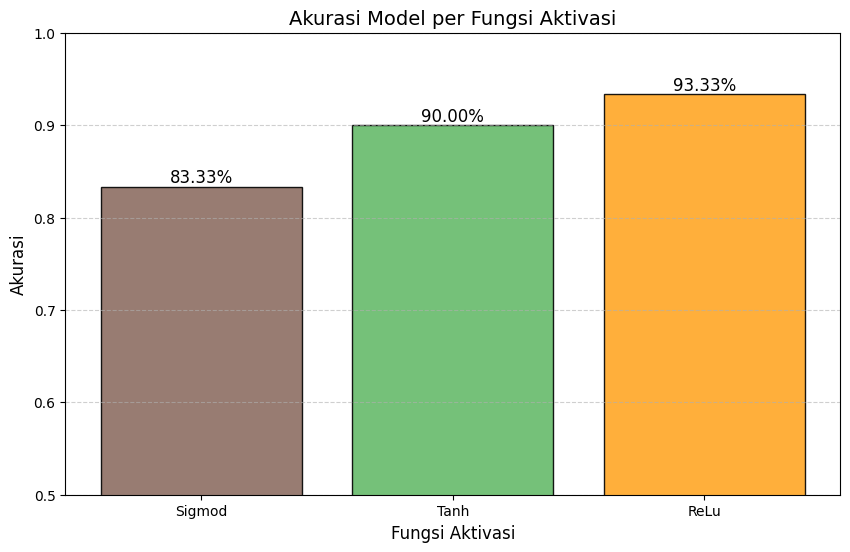

In [14]:
# Visualisasi Akurasi

plt.figure(figsize=(10, 6))
colors = ['#8D6E63', '#66BB6A', '#FFA726']
bars = plt.bar(results_df['Fungsi Aktivasi'], results_df['Akurasi'], color=colors, edgecolor='black', alpha=0.9)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2%}', ha='center', va='bottom', fontsize=12)
plt.title('Akurasi Model per Fungsi Aktivasi', fontsize=14)
plt.xlabel('Fungsi Aktivasi', fontsize=12)
plt.ylabel('Akurasi', fontsize=12)
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [15]:
# Classification Report

for name in results:
    print(f"\nClassification Report - {name}:\n{results[name]['report']}")


Classification Report - Sigmod:
                 precision    recall  f1-score   support

    Iris-setosa       0.91      1.00      0.95        10
Iris-versicolor       0.69      0.90      0.78        10
 Iris-virginica       1.00      0.60      0.75        10

       accuracy                           0.83        30
      macro avg       0.87      0.83      0.83        30
   weighted avg       0.87      0.83      0.83        30


Classification Report - Tanh:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.89      0.80      0.84        10
 Iris-virginica       0.82      0.90      0.86        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30


Classification Report - ReLu:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1

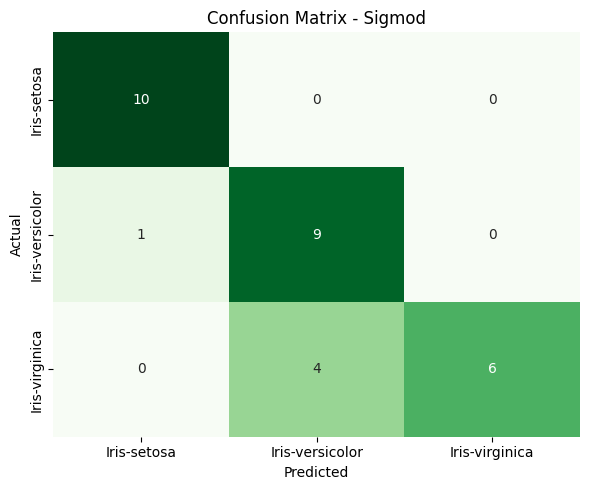

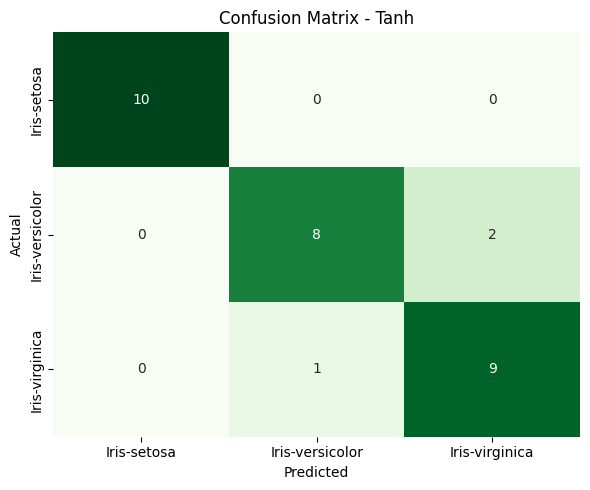

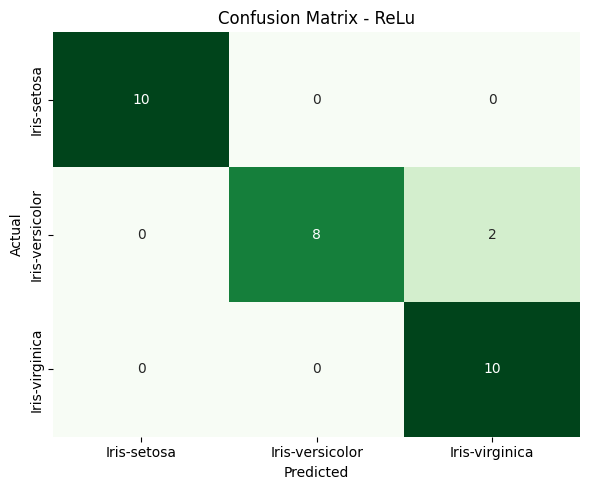

In [16]:
# Confusion Matrix

for name in results:
    y_pred = results[name]['model'].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=le.classes_, yticklabels=le.classes_,
                cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()  
    plt.show()

## Project's Encapsulate

Berdasarkan hasil pengujian MLP pada dataset Iris, fungsi aktivasi ReLU memberikan performa terbaik dibandingkan fungsi aktivasi lainnya. Hal ini disebabkan oleh proses komputasinya yang lebih sederhana serta kemampuannya menjaga aliran gradien selama proses pelatihan, sehingga masalah vanishing gradient dapat diminimalkan. Sebaliknya, fungsi Sigmoid dan Tanh cenderung mengalami saturasi pada nilai tertentu, yang menyebabkan gradien menjadi sangat kecil dan memperlambat proses pembelajaran jaringan saraf.

Fungsi Sigmoid menghasilkan tingkat akurasi terendah, yaitu 83,33%, karena penurunan gradien yang signifikan membuat model kurang efektif dalam mempelajari karakteristik data yang kompleks.

Sementara itu, fungsi Tanh memperoleh akurasi sebesar 90,00% dan menunjukkan kinerja yang lebih baik dibandingkan Sigmoid. Meskipun demikian, Tanh masih memiliki kelemahan berupa kemungkinan terjadinya saturasi dan kebutuhan komputasi yang lebih tinggi akibat penggunaan operasi eksponensial, sehingga performanya belum mampu melampaui ReLU.